# Análise Exploratória de Vendas de Videogames

**Disciplina:** Estatística | **Integrantes:**                                                                                                                         
- Arthur Sindeaux de Araújo Nogueira
- Guilherme Tolentino Leitão de Melo
- Rafael Coutinho Lima
- Lucas Pinto Ribeiro Beno
- Pedro Coutinho da Silva
- Arthur Oliveira Furieri
- João Henrique Bastos
- João Eduardo Azevedo de Andrade

## Problema principal

Analisar as vendas de títulos de videogame para entender como o desempenho comercial se distribui entre gêneros, plataformas e regiões.

## Perguntas de investigação e hipóteses

**Pergunta 1.** Como se distribui o desempenho comercial dos títulos, e quão concentrado está o mercado em poucos lançamentos?

*Hipótese 1:* a distribuição é fortemente assimétrica à direita, com média bastante superior à mediana e o terceiro quartil ainda em patamar baixo. Se confirmado, o jogo mediano vende uma fração do que a média sugere, e a média é uma métrica enganosa para planejar um lançamento.

**Pergunta 2.** O desempenho de um título em um mercado se repete nos demais, ou cada região tem dinâmica própria?

*Hipótese 2:* as receitas regionais não se movem juntas de forma uniforme. Esperamos divergência entre Pearson e Spearman, porque Pearson é dominado pelos poucos títulos gigantes enquanto Spearman descreve o jogo típico. Se as duas medidas apontarem direções diferentes, a previsibilidade entre mercados só existe na faixa dos grandes sucessos.

**Pergunta 3.** Gêneros e plataformas com mais lançamentos são também os de melhor desempenho típico?

*Hipótese 3:* volume de lançamentos não acompanha desempenho mediano. Esperamos que categorias mais exploradas apresentem mediana comprimida por saturação.

## Fonte dos dados

Dataset `vgsales.csv` (Video Game Sales, Kaggle), com estimativas de vendas em milhões de unidades. Cada linha representa **um jogo em uma plataforma específica**: o mesmo título lançado em dois consoles ocupa duas linhas.

# 1 Config do Ambiente

In [39]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np


In [40]:
import sys
print(sys.executable)

c:\Users\arthu\OneDrive\Documents\Prontuario\venv\Scripts\python.exe


## 2. Carga e reconhecimento inicial dos dados

In [41]:
df = pd.read_csv("data/vgsales.csv")

print("Linhas e colunas:", df.shape)
df.head()
df.info()
df.describe()

Linhas e colunas: (16598, 11)
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


**Leitura inicial.** A base tem 16.598 registros e 11 colunas. Já aparecem dois problemas a tratar: `Year` foi lida como decimal, o que é sintoma de valores ausentes, e as colunas de venda têm média muito distante do máximo, primeiro indício da assimetria que a Pergunta 1 investiga.

## 3. Pré-processamento


In [42]:
nulos = pd.DataFrame({
    "ausentes": df.isnull().sum(),
    "percentual": (df.isnull().sum() / len(df) * 100).round(2)
})
nulos[nulos["ausentes"] > 0]

,ausentes,percentual
Year,271,1.63
Publisher,58,0.35


**Diagnóstico de nulos.** Apenas duas colunas têm ausências e ambas em volume pequeno: `Year` (1,63%) e `Publisher` (0,35%). Nenhuma coluna de vendas tem valor faltante, o que importa porque as perguntas de investigação dependem exclusivamente delas. Antes de aplicar o tratamento, verificamos as duplicatas: parte das linhas repetidas tem justamente `Year` ausente, e é preciso saber quais casos estão saindo da base por esse critério.

### 3.1 Tratamento de valores ausentes

Optamos por remover as linhas com valores ausentes em vez de imputar. `Year` representa 1,63% dos registros e não há como estimar um ano de lançamento sem inventar informação; `Publisher` são 0,35%. Somadas, a perda fica abaixo de 2% e nenhuma coluna de vendas é afetada, de modo que as medidas descritivas de `Global_Sales` permanecem íntegras.

In [43]:
antes = len(df)
df = df.dropna()
print(f"Removidas {antes - len(df)} linhas com valores ausentes. Restam {len(df)} registros.")
print(f"Perda: {(antes - len(df)) / antes * 100:.2f}%")
print("Nulos rest antes:", df.isnull().sum().sum())

Removidas 307 linhas com valores ausentes. Restam 16291 registros.
Perda: 1.85%
Nulos rest antes: 0


## 4. Distribuição das vendas globais (Pergunta 1)

Com a base tratada, passamos à pergunta 1. Começamos pelas
medidas de tendência central e de dispersão de `Global_Sales`, que já permitem
uma primeira leitura sobre a forma da distribuição.

In [44]:
vendas = df["Global_Sales"]

media   = vendas.mean()
mediana = vendas.median()
moda    = vendas.mode().iloc[0]
desvio  = vendas.std()
cv      = desvio / media * 100
Q1, Q3  = vendas.quantile([0.25, 0.75])
IQR     = Q3 - Q1

print(f"N:                {len(vendas)}")
print(f"Média:            {media:.3f} M")
print(f"Mediana (Q2):     {mediana:.3f} M")
print(f"Moda:             {moda:.3f} M")
print(f"Mínimo / Máximo:  {vendas.min():.2f} / {vendas.max():.2f} M")
print(f"Amplitude:        {vendas.max() - vendas.min():.2f} M")
print(f"Desvio-padrão:    {desvio:.3f}")
print(f"CV:               {cv:.1f}%")
print(f"Q1 / Q3 / IQR:    {Q1:.3f} / {Q3:.3f} / {IQR:.3f}")

N:                16291
Média:            0.541 M
Mediana (Q2):     0.170 M
Moda:             0.020 M
Mínimo / Máximo:  0.01 / 82.74 M
Amplitude:        82.73 M
Desvio-padrão:    1.567
CV:               289.8%
Q1 / Q3 / IQR:    0.060 / 0.480 / 0.420


**Leitura das medidas.** A média (0,541 M) é mais de três vezes a mediana (0,170 M) e a moda está em 0,02 M: as três medidas de tendência central não coincidem, e a ordem moda < mediana < média é a assinatura de uma distribuição assimétrica à direita. O CV de quase 290% confirma dispersão enorme em relação ao centro. O terceiro quartil (0,48 M) mostra que 75% dos títulos vendem menos de meio milhão de unidades, embora o máximo chegue a 82,74 M.

### 4.1 Forma da distribuição: assimetria e curtose

As medidas anteriores sugerem a forma da distribuição; assimetria e curtose a quantificam. A assimetria mede o quanto a cauda se estende para um dos lados (zero em uma distribuição simétrica) e a curtose, o peso das caudas em relação à normal (excesso zero na normal).

In [45]:
assimetria = vendas.skew()
curtose    = vendas.kurtosis()

top1 = vendas.nlargest(int(len(vendas) * 0.01)).sum() / vendas.sum() * 100

print(f"Assimetria (skewness): {assimetria:.2f}")
print(f"Curtose (excesso):     {curtose:.2f}")
print(f"Média / Mediana:       {media:.3f} / {mediana:.3f} M  (razão {media/mediana:.2f}x)")
print(f"Títulos acima da média: {(vendas > media).mean()*100:.1f}%")
print(f"Vendas concentradas nos 1% maiores títulos: {top1:.1f}%")

Assimetria (skewness): 17.30
Curtose (excesso):     596.00
Média / Mediana:       0.541 / 0.170 M  (razão 3.18x)
Títulos acima da média: 22.3%
Vendas concentradas nos 1% maiores títulos: 21.1%


**Leitura da forma.** Assimetria de 17,3 e curtose de 596 são valores extremos: a distribuição é fortemente assimétrica à direita e com cauda muito pesada, bem distante de uma normal (assimetria 0, curtose 0). Apenas 22,3% dos títulos vendem acima da média, ou seja, a média é puxada por poucos lançamentos gigantes e não representa o jogo típico. O 1% de títulos mais vendidos (cerca de 160 jogos) responde por 21,1% de todas as unidades vendidas na base. Esses números respondem à parte quantitativa da Pergunta 1; a seguir visualizamos a distribuição para confirmar a leitura.

### 4.2 Visualização: histograma e boxplot

O histograma mostra a forma da distribuição e o boxplot destaca a mediana, o IQR e os valores atípicos (outliers), definidos aqui pela regra de Tukey: acima de Q3 + 1,5·IQR.

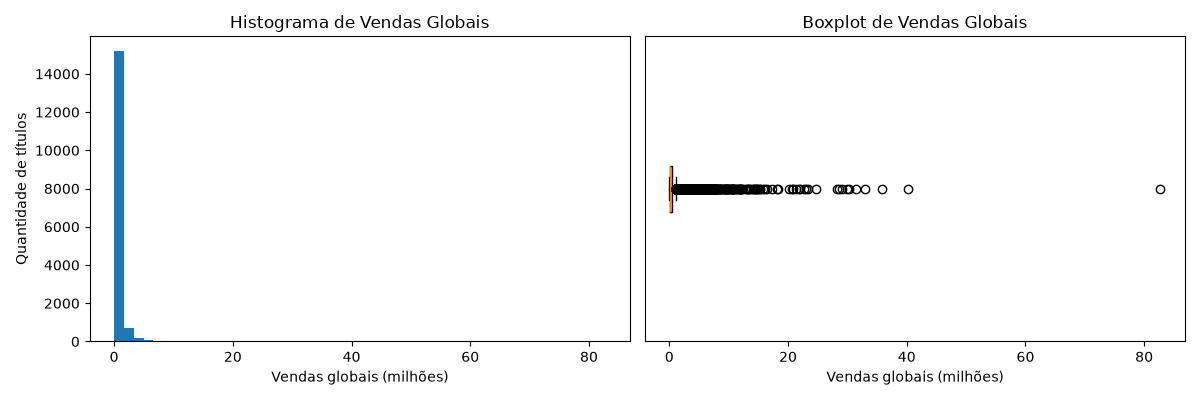

Limite superior do boxplot (Q3 + 1,5·IQR): 1.11 M
Títulos acima do limite (outliers): 1826 (11.2%)


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vendas, bins=50)
axes[0].set_title("Histograma de Vendas Globais")
axes[0].set_xlabel("Vendas globais (milhões)")
axes[0].set_ylabel("Quantidade de títulos")

axes[1].boxplot(vendas, orientation="horizontal")
axes[1].set_title("Boxplot de Vendas Globais")
axes[1].set_xlabel("Vendas globais (milhões)")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

limite_sup = Q3 + 1.5 * IQR
outliers   = (vendas > limite_sup).sum()
print(f"Limite superior do boxplot (Q3 + 1,5·IQR): {limite_sup:.2f} M")
print(f"Títulos acima do limite (outliers): {outliers} ({outliers/len(vendas)*100:.1f}%)")

**Leitura dos gráficos.** O histograma concentra praticamente todos os títulos na primeira barra (até cerca de 1,7 M) e o restante do eixo, até 82,74 M, é ocupado por uma cauda longa quase invisível. No boxplot, a caixa (Q1 a Q3) fica comprimida entre 0,06 M e 0,48 M e os 1.826 outliers (11,2% da base) se espalham à direita, com o título de 82,74 M isolado no extremo. O quadro visual coincide com as medidas: mercado concentrado em poucos lançamentos e um jogo típico que vende uma fração do que a média sugere, o que confirma a Hipótese 1.